# Push fleet model — demo & smoke test

Runs Paco's delivery-driven (**"push"**) fleet engine as a selectable AeroMAPS
efficiency model (`models_efficiency_push`) over the TP/RJ/NB/WB passenger
segments (`markets_push.yaml`).

**The push engine is calibrated to the end-2024 fleet**, so a scenario using it
**must pivot on 2024** (`prospection_start_year = 2025`). This demo uses the
ad-hoc 2000–2024 historic vectors from
`tutorials/13_change_the_prospection_start_year` (`inputs_2025.json`), wired via
`data/config_push_2025.yaml`, and runs to `end_year = 2070`.

Per-segment demand growth follows the **legacy push profile**, now expressed as
the markets' `inputs.growth.cagr_reference_periods` (ported from the engine's old
`default_market_param.yaml::reference_growth`), so the injected ASK matches the
trajectory the fleet was calibrated against.

Scope: the drop-in efficiency bridge (energy-per-ASK + 100 % drop-in shares)
**plus** the push model's distinguishing fleet state — per-segment & per-type
**fleet counts** and **deliveries** — surfaced as AeroMAPS outputs, and the
model's own `plot()` method for the diagnostic charts.

> **Note.** The engine still raises `ValueError` if delivered capacity can't meet
> demand in any year (legacy fail-loud behaviour) — this calibrated scenario just
> doesn't trip it anymore.

In [12]:
import warnings
import matplotlib.pyplot as plt
from aeromaps import create_process

warnings.simplefilter("ignore")  # quiet the reference-year notices + push feasibility logs

# CWD is the notebook dir; the config's paths are relative to itself.
process = create_process(configuration_file="data/config_push_2025.yaml")
process.compute()

print("prospection_start_year :", process.parameters.prospection_start_year)
print("last_historical_year   :", process.parameters.last_historical_year, "(engine pivot = 2024)")

prospection_start_year : 2025
last_historical_year   : 2024 (engine pivot = 2024)


## Per-segment energy-per-ASK

History (≤ 2024) is spliced from the AeroMAPS `energy_consumption_init / ask_init`
× the segment's 2024 energy/RPK shares; the projection (≥ 2025) is produced
bottom-up by the push engine from the surviving + delivered fleet. The 2024→2025
seam is smooth because both sides are now anchored on 2024.

In [13]:
segments = ["TP", "RJ", "NB", "WB"]  # market id == push engine segment label
df = process.data["vector_outputs"]

print(f"{'segment':14s}{'2024':>10s}{'2025':>10s}{'2050':>10s}   (MJ/ASK)")
for mid in segments:
    s = df[f"energy_per_ask_without_operations_{mid}_dropin_fuel"]
    print(f"{mid:14s}{s.loc[2024]:10.4f}{s.loc[2025]:10.4f}{s.loc[2050]:10.4f}")

segment             2024      2025      2050   (MJ/ASK)
TP                1.8602    1.8371    0.8980
RJ                2.2569    2.2131    1.3570
NB                1.1077    1.0832    0.3616
WB                1.1537    1.1387    0.8085


## Fleet counts & deliveries (the push model's distinguishing state)

The push engine drives the fleet from aircraft **deliveries** and lets
retirement + utilisation curves determine the surviving fleet. Phase 5 surfaces
that native state as AeroMAPS outputs, mirroring `SimpleFleetCount`'s naming:

- `"<Segment>: Aircraft In Fleet"` — per-segment total fleet count.
- `<mid>:<aircraft_type>:aircraft_in_fleet` — per-type fleet count.
- `<mid>:<aircraft_type>:aircraft_deliveries` — per-type new deliveries per year.

**Year alignment.** Fleet counts are indexed at `last_historical_year + t`
(t = 0 is the 2024 pivot, carrying the calibrated end-2024 fleet snapshot);
deliveries at `first_projection_year + k` (2025 + k). Pre-pivot history
(2000–2023) is left NaN — the engine has no fleet state there.

In [14]:
segment_names = {
    "TP": "Turboprop",
    "RJ": "Regional Jet",
    "NB": "Narrow Body",
    "WB": "Wide Body",
}

# Sanity table: per-segment fleet count & total deliveries at 2025 / 2035 / 2050.
hdr = f"{'segment':14s}" + "".join(f"{y:>14s}" for y in ("count25", "count35", "count50"))
hdr += "".join(f"{y:>12s}" for y in ("deliv25", "deliv35", "deliv50"))
print(hdr)
for mid, name in segment_names.items():
    total = df[f"{name}: Aircraft In Fleet"]
    deliv_cols = [
        c for c in df.columns if c.startswith(f"{mid}:") and c.endswith(":aircraft_deliveries")
    ]
    deliv = df[deliv_cols].sum(axis=1)
    row = f"{mid:14s}"
    row += "".join(f"{total.loc[y]:14.1f}" for y in (2025, 2035, 2050))
    row += "".join(f"{deliv.loc[y]:12.1f}" for y in (2025, 2035, 2050))
    print(row)

segment              count25       count35       count50     deliv25     deliv35     deliv50
TP                    3843.6        2273.1        2254.4        20.0       196.3       110.4
RJ                    3934.8        3752.6        3407.5        60.0        94.9        73.7
NB                   20997.1       22574.1       26463.3       650.0      1981.3       847.1
WB                    5227.0        5348.9        6406.0       110.0       208.7       477.9


### Diagnostic plots (the model's own `plot()` method)

All push charts are rendered by `PassengerAircraftEfficiencyFleetPush.plot()`,
mirroring `FleetModel.plot()`. `compute()` caches the engine's per-segment
**age-resolved** arrays (`self._engine_results`), and `plot()` draws, per segment:
the fleet / ASK / deliveries / energy stacks, the **retirement** and
**retirement-age** diagnostics (which need those internal `(periods, age, type)`
arrays, so they can't be `SingleScenarioPlot` registry plots), and the
energy-intensity curve. The matplotlib helpers live in
`fleet_model_push_visualisations.py`.

['ASK evolution', 'Aircraft seats evolution', 'Aircraft production', 'Aircraft seats production', 'Aircraft seats retirements', 'Aircraft ASKs losses', 'Operating and retirement ages', 'Energy consumption', 'Energy efficiency']


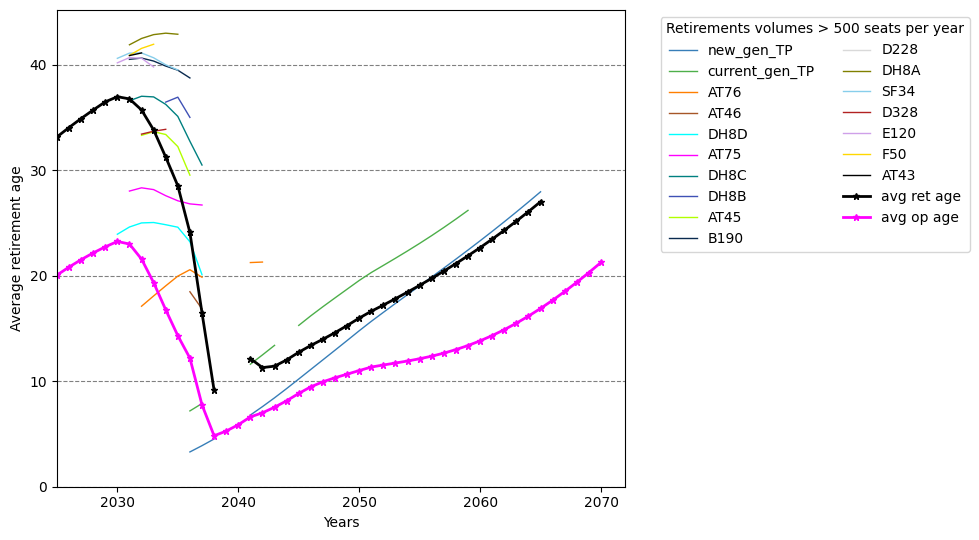

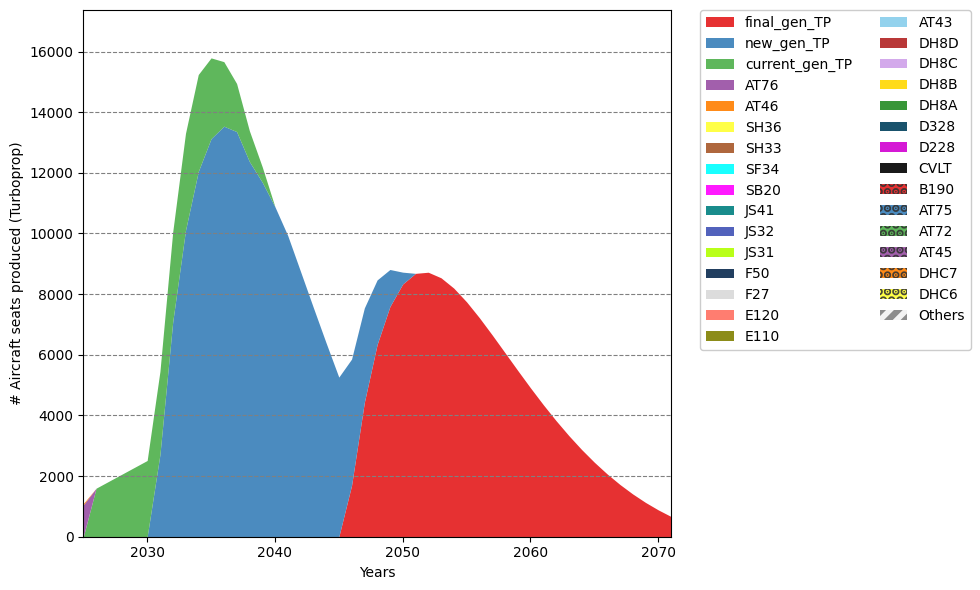

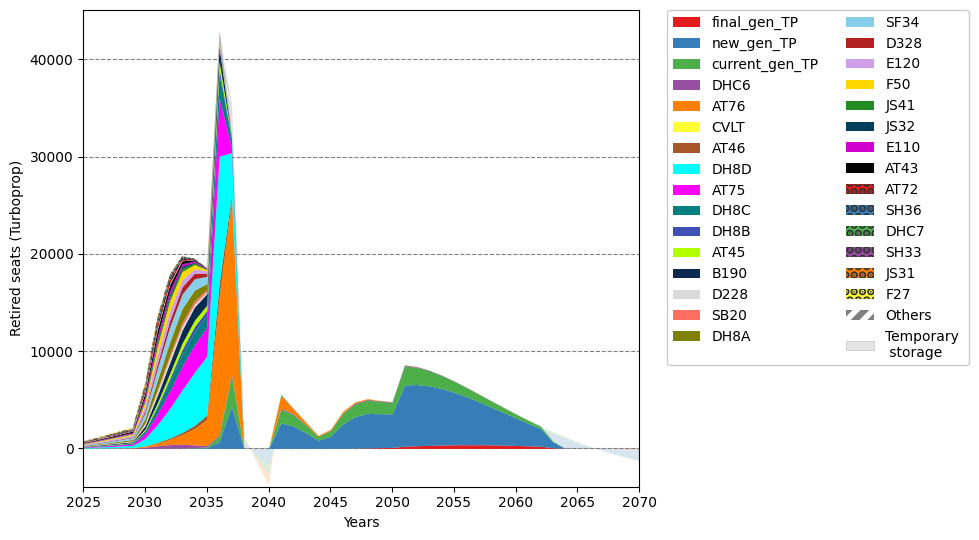

In [17]:
# The push model is exposed directly on the process (mirrors `process.fleet_model`).
# Render every push chart per segment:
# fleet / ASK / deliveries / retirements / retirement-age / energy / energy-intensity.
push_model = process.push_fleet_model
push_model.list_available_plots()
push_model.plot('Operating and retirement ages', "TP")
push_model.plot("Aircraft seats production", "TP")
push_model.plot("Aircraft seats retirements", "TP")
plt.show()

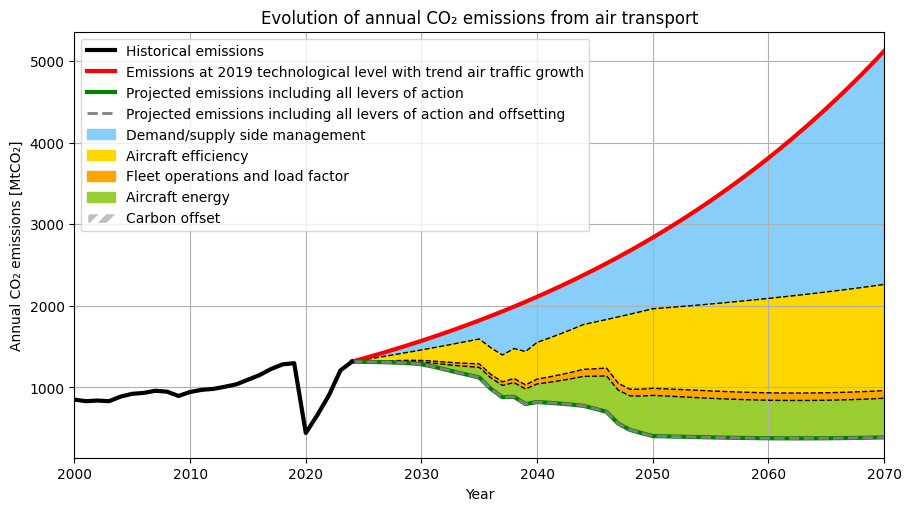

In [16]:
process.plot("air_transport_co2_emissions")

## Guard: the push model requires a 2024 pivot

Selecting `models_efficiency_push` on any other pivot (e.g. the default
`prospection_start_year = 2020`) fails fast at build time, rather than silently
mis-dating the 2024 fleet.

In [ ]:
import tempfile
import yaml
from pathlib import Path

# The scenario markets file lives next to this notebook (CWD = notebook dir). The bad
# config is written to a temp dir, so pass markets_push.yaml as an absolute path.
markets_push = str(Path("data/markets_push.yaml").resolve())
bad_cfg = {  # no data.inputs -> prospection_start_year defaults to 2020
    "models": {
        "markets": {"markets_data_file": markets_push},
        "climate": {"climate_model_data_file": "default"},
        "energy": {
            "energy_carriers_model_data_file": "default",
            "resources_model_data_file": "default",
            "processes_model_data_file": "default",
        },
        "standards": [
            "models_traffic",
            "models_efficiency_push",
            "models_energy_without_fuel_effect",
            "models_offset",
            "models_emissions",
            "models_sustainability",
            "models_energy_cost",
            "models_operation_cost_top_down",
        ],
    },
}
with tempfile.NamedTemporaryFile("w", suffix=".yaml", delete=False) as f:
    yaml.safe_dump(bad_cfg, f)
    tmp = f.name

try:
    create_process(configuration_file=tmp)
    print("No error (unexpected).")
except ValueError as e:
    print("Guard fired as expected:\n")
    print(e)

## Adding or removing a segment (market / aircraft category)

The push model uses **one name for each segment**: a passenger market's AeroMAPS
**id is identical to the push engine's segment label** (the `market:` value in
`default_aircraft_classification.yaml`, e.g. `TP` / `RJ` / `NB` / `WB`). There is
**no mapping table in the code** — the wrapper drives any market whose id matches
an engine segment, and holds any other passenger market flat (with a warning). So
adding or removing a segment is a **data-only** change; no Python edit is needed.

### To add a segment (say `BJ`, business jets)

All files below live under `aeromaps/resources/data/default_fleet_push/` (engine
config) and the calibration folder
`aeromaps/utils/calibration_notebooks/fleet_calibrated_inputs_processed_here/`
(Excel), except the markets profile which is this notebook's `data/markets_push.yaml`.

1. **Classify the aircraft types** → in `default_aircraft_classification.yaml`,
   tag every relevant `Aircraft Type` with the new label, e.g. `- E55P : 'BJ'`.
2. **Calibration data** → make sure `aircraft_type_key_parameters.xlsx`
   (seats, km/yr, MJ/ASK …) and `agg_fleet_end_2024.xlsx` (end-2024 counts)
   contain rows for those aircraft types.
3. **In-production & future aircraft** → add a `BJ:` block under `markets:` in
   `default_in_production_aircraft_inventory.yaml` and
   `default_new_aircraft_inventory.yaml` (same schema as the existing segments).
4. **Age sensibilities** → add a `BJ:` block under `markets:` in
   `default_market_param.yaml` (`age_utilisation_sensib`, `age_retirement_sensib`).
5. **Declare the market** → add a block to `data/markets_push.yaml` whose **key is
   the segment label** (`BJ:`), with `name`, `traffic_type: passenger`,
   `traffic_unit: RPK`, the `initial` shares (`rpk_share_last_historical_year`,
   `energy_share_last_historical_year`) and a `growth` profile. The shares are
   regenerable: run `generate_push_markets.py`, which reads them straight from the
   classification YAML + the calibration Excel.

Re-run this notebook — the new segment appears automatically in every output
(`energy_per_ask_without_operations_BJ_*`, `BJ:<type>:aircraft_in_fleet`, …) and in
`plot()`. Add `"BJ"` to the `segments` / `segment_names` lists above to include it
in the summary tables.

### To remove a segment

Delete its block from `data/markets_push.yaml` (the engine simply stops being run
for it). You may also drop it from the engine YAMLs above for tidiness, but it is
not required — a segment present in the engine config but absent from
`markets_push.yaml` is just never consumed. The reverse (a passenger market with
**no** matching engine segment) is tolerated too: its history is spliced and the
last value held flat over the projection, with a warning in the log.


In [11]:
from aeromaps.utils.calibration_notebooks.fleet_calibrated_inputs_processed_here.generate_push_markets import compute_segment_shares
compute_segment_shares()

{'NB': {'rpk_share': 55.4922, 'energy_share': 52.7338},
 'RJ': {'rpk_share': 2.726, 'energy_share': 5.278},
 'TP': {'rpk_share': 1.0461, 'energy_share': 1.6694},
 'WB': {'rpk_share': 40.7357, 'energy_share': 40.3188}}